## Setup

In [15]:
%load_ext autoreload
%autoreload 2
%aimport

%matplotlib inline 

import torch
import matplotlib.pyplot as plt
from einops import rearrange

from bliss.catalog import TileCatalog, get_images_in_tiles
from bliss.encoder import Encoder


device = torch.device('cuda:0')
!echo $CUDA_VISIBLE_DEVICES

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Modules to reload:
all-except-skipped

Modules to skip:

4


## Load Models

In [16]:
# load models
from hydra import compose, initialize
from hydra.utils import instantiate

with initialize(config_path="../../../case_studies/coadds/config"):
    cfg = compose("config", overrides=[])

In [17]:
location = instantiate(cfg.models.detection_encoder).to(device).eval()
# NOTE: change weight_checkpoint to the one in your output folder
location.load_state_dict(torch.load('./case_studies/coadds/models/encoder.pt', map_location=location.device)
)

encoder = Encoder(location.eval(), n_images_per_batch=10, n_rows_per_batch=15).to(device).eval()

In [18]:
location_coadd = instantiate(cfg.models.detection_encoder).to(device).eval()
location_coadd.load_state_dict(torch.load('./case_studies/coadds/models/coadd_encoder.pt', map_location=location_coadd.device)
)

encoder_coadd = Encoder(location_coadd.eval(), n_images_per_batch=10, n_rows_per_batch=15).to(device).eval()

## Load Coadd Dataset

In [19]:
with initialize(config_path="../../../case_studies/coadds/config"):
    cfg = compose("config", overrides=[])

In [20]:
# should be ONLY stars
cfg.datasets.galsim_blends_coadds.prior.galaxy_prob

0.0

In [21]:
cfg.datasets.galsim_blends_coadds.prior.n_dithers = 10

In [22]:
ds = instantiate(cfg.datasets.galsim_blends_coadds, batch_size=64, n_batches=100, num_workers=20)

Generating dataset: 100%|██████████| 100/100 [00:37<00:00,  2.64it/s]


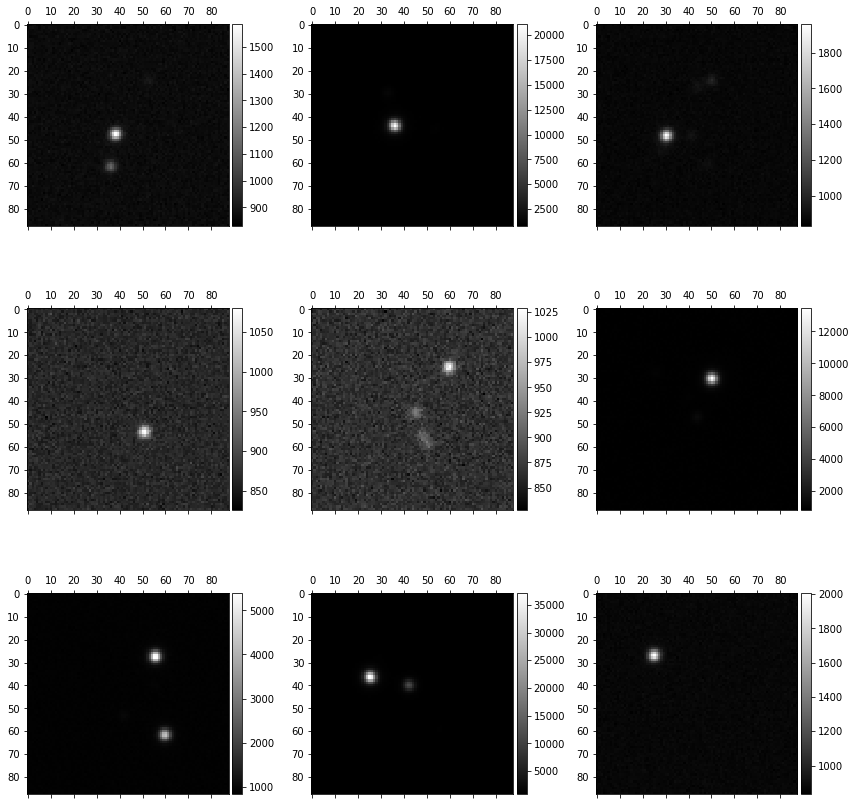

In [23]:
from bliss.generate import generate
generate(ds, '/home/wmallory/bliss/case_studies/coadds/output/coadd_dataset2.pt', '/home/wmallory/bliss/case_studies/coadds/output/coadd_dataset2.png', 9, global_params=("background",))


## Run Model on saved datset

In [24]:
sds = torch.load('/home/wmallory/bliss/case_studies/coadds/output/coadd_dataset2.pt')
sds['images'].shape, sds['noisy'].shape, sds['n_sources'].shape

(torch.Size([6400, 1, 88, 88]),
 torch.Size([6400, 1, 88, 88]),
 torch.Size([6400, 10, 10]))

In [25]:
# format background (needs to be CONSTANT)
n_batches = sds['images'].shape[0]
slen = sds['images'].shape[-1]
background = rearrange(sds['background'], '1 h w -> 1 1 h w')
background = background.expand(n_batches, 1, slen, slen)

In [26]:
# run (single-exposure) model prediction 
tile_est = encoder.variational_mode(sds['noisy'], background)

Encoding ptiles: 640it [00:21, 30.42it/s]


In [27]:
# run (coadd) model prediction 
tile_est_coadd = encoder_coadd.variational_mode(sds['images'], background)

Encoding ptiles: 640it [00:23, 27.24it/s]


## Metric on prediction compared to truth

In [28]:
# load true catalog
catalog_dict = {
    "locs": sds["locs"],
    "star_log_fluxes": sds["star_log_fluxes"],
    "galaxy_bools": sds["galaxy_bools"],
    "n_sources": sds["n_sources"],
    "star_fluxes": sds['star_fluxes']
}

In [29]:
true_tile_catalog = TileCatalog(4, catalog_dict)
truth = true_tile_catalog.to_full_params()

## Encoder

In [30]:
est = tile_est.cpu().to_full_params() # full estimated catalog from single exposure model
est['galaxy_bools'] = torch.zeros(est.batch_size, est.max_sources, 1) # only stars, did not train classification encoder

### Simple metrics

In [31]:
# encoder
from bliss.reporting import DetectionMetrics
metrics = DetectionMetrics()(truth, est)

In [32]:
metrics['f1'], metrics['precision'], metrics['recall']

(tensor(0.8755), tensor(0.9320), tensor(0.8254))

## Flux prediction

In [33]:
from bliss.reporting import match_by_locs

In [34]:
# encoder
true_plocs = truth.plocs
est_plocs = est.plocs

In [58]:
# obtain fluxes of matches
true_fluxes = []
est_fluxes = [] 
for ii in range(true_plocs.shape[0]):
    n_sources1, n_sources2 = truth.n_sources[ii].item(), est.n_sources[ii].item()
    if n_sources1 > 0 and n_sources2 > 0:
        plocs1 = true_plocs[ii]
        plocs2 = est_plocs[ii]
        mtrue, mest, dkeep, avg_distance = match_by_locs(plocs1, plocs2)
        tp = len(plocs2[mest][dkeep])  # n_matches
        
        fluxes1 = truth['star_fluxes'][ii][mtrue][dkeep]
        fluxes2 = est['star_fluxes'][ii][mest][dkeep]
        for jj in range(tp):
            flux1 = fluxes1[jj].item()
            flux2 = fluxes2[jj].item()
            assert flux1 > 0 and flux2 > 0
            true_fluxes.append(flux1)
            est_fluxes.append(flux2)

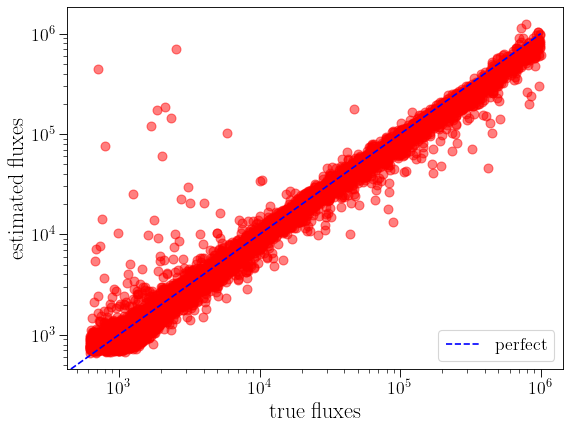

In [64]:
from matplotlib.pyplot import figure

figure(figsize=(8, 6), dpi=80)
plt.scatter(true_fluxes, est_fluxes, marker='o', color='r', alpha=0.5)
plt.plot([0, 1e6], [0, 1e6], 'b--', label='perfect')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('true fluxes')
plt.ylabel('estimated fluxes')
plt.legend(loc="lower right",prop={"size": 16})

In [71]:
import pandas as pd
d = {'true': true_fluxes, 'est': est_fluxes}
fluxes = pd.DataFrame(d)

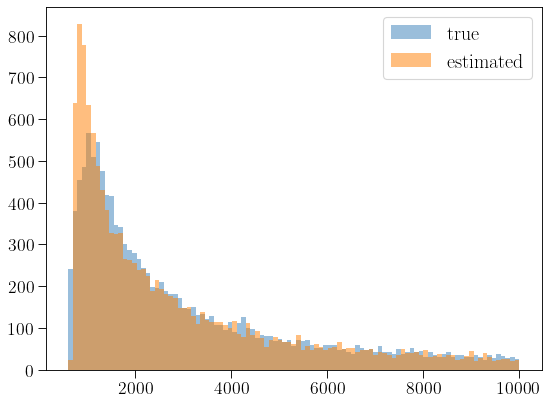

In [81]:
from matplotlib import pyplot
figure(figsize=(8, 6), dpi=80)
bins = np.linspace(600, 10000, 100)
pyplot.hist(fluxes['true'], bins, alpha=0.5, label='true')
pyplot.hist(fluxes['est'], bins, alpha=0.5, label='estimated')
pyplot.legend(loc='upper right')
pyplot.show()

In [75]:
max(fluxes['true'])


997155.0

## Add magnitude to truth and estimated catalog

In [37]:
# NOTE: need to add 'mag' to catalog
# ASSUMES only stars
from bliss.datasets.sdss import convert_flux_to_mag
truth['mags'] = torch.zeros_like(truth['star_fluxes'])
for ii in range(len(truth.n_sources)):
    n_sources = truth.n_sources[ii].item()
    truth['mags'][ii, :n_sources] = convert_flux_to_mag(truth['star_fluxes'][ii, :n_sources])

In [38]:
# NOTE: need to add 'mag' to catalog
# ASSUMES only stars
from bliss.datasets.sdss import convert_flux_to_mag
est['mags'] = torch.zeros_like(est['star_fluxes'])
for ii in range(len(est.n_sources)):
    n_sources = est.n_sources[ii].item()
    est['mags'][ii, :n_sources] = convert_flux_to_mag(est['star_fluxes'][ii, :n_sources])

In [39]:
# first check scene_metrics works for one bin 
from bliss.reporting import scene_metrics
import numpy as np

In [40]:
results = scene_metrics(truth, est, mag_min=-np.inf, mag_max=18)

In [41]:
from tqdm import tqdm
from collections import defaultdict
from case_studies.sdss_galaxies.plots.bliss_figures import set_rc_params, format_plot, CB_color_cycle

def compute_mag_bin_metrics(mag_bins, truth, pred):
    metrics_per_mag = defaultdict(lambda: torch.zeros(len(mag_bins)))

    # compute data for precision/recall/classification accuracy as a function of magnitude.
    for ii, (mag1, mag2) in tqdm(enumerate(mag_bins), total=len(mag_bins)):
        res = scene_metrics(truth, pred, mag_min=mag1, mag_max=mag2, slack=1.0)
        metrics_per_mag["precision"][ii] = res["precision"]
        metrics_per_mag["recall"][ii] = res["recall"]
        metrics_per_mag["f1"][ii] = res["f1"]
        metrics_per_mag["class_acc"][ii] = res["class_acc"]
        conf_matrix = res["conf_matrix"]
        metrics_per_mag["galaxy_acc"][ii] = conf_matrix[0, 0] / conf_matrix[0, :].sum().item()
        metrics_per_mag["star_acc"][ii] = conf_matrix[1, 1] / conf_matrix[1, :].sum().item()
        for k, v in res["counts"].items():
            metrics_per_mag[k][ii] = v

    return dict(metrics_per_mag)


def make_detection_figure(
    mags,
    data,
    xlims=(18, 24),
    ylims=(0.7, 1.05),
    ratio=1,
    where_step="mid",
    n_gap=50,
):
    # precision / recall / f1 score
    precision = data["precision"].numpy()
    recall = data["recall"].numpy()
    f1_score = data["f1"].numpy()
    tgcount = data["tgcount"].numpy()
    tscount = data["tscount"].numpy()
    egcount = data["egcount"].numpy()
    escount = data["escount"].numpy()
    # (1) precision / recall
    set_rc_params(tick_label_size=16, label_size=20)
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(10, 10), gridspec_kw={"height_ratios": [1, ratio]}, sharex=True
    )
    
    ymin = min(min(precision), min(recall))
    yticks = np.arange(np.round(ymin, 1), 1.1, 0.1)
    format_plot(ax2, xlabel=r"\rm magnitude cut", ylabel="metric", yticks=yticks)
    ax2.plot(mags[:, 1], recall, "-o", label=r"\rm recall")
    ax2.plot(mags[:, 1], precision, "-o", label=r"\rm precision")
    ax2.plot(mags[:, 1], f1_score, "-o", label=r"\rm f1 score")
    ax2.legend(loc="lower left", prop={"size": 16})
    ax2.set_xlim(xlims)
    ax2.set_ylim(ylims)
    ax2.yaxis.get_ticklocs(minor=True)
    ax2.minorticks_on()

    # setup histogram plot up top.
    c1 = CB_color_cycle[3]
    c2 = CB_color_cycle[4]
    ax1.step(mags[:, 1], tscount, label="truth stars", where=where_step, color=c2)
    ax1.step(mags[:, 1], escount, label="pred. stars", ls="--", where=where_step, color=c2)

    format_plot(ax1, ylabel=r"\rm counts")
    ax1.legend(loc="best", prop={"size": 16})
    plt.subplots_adjust(hspace=0)
    return fig

In [43]:
mag_cuts2 = torch.arange(17.5, 23.5, 0.5)
mag_cuts1 = torch.full_like(mag_cuts2, fill_value=-np.inf)
mag_cuts = torch.column_stack((mag_cuts1, mag_cuts2))

In [44]:
data = compute_mag_bin_metrics(mag_cuts, truth, est)

100%|██████████| 12/12 [03:59<00:00, 19.96s/it]


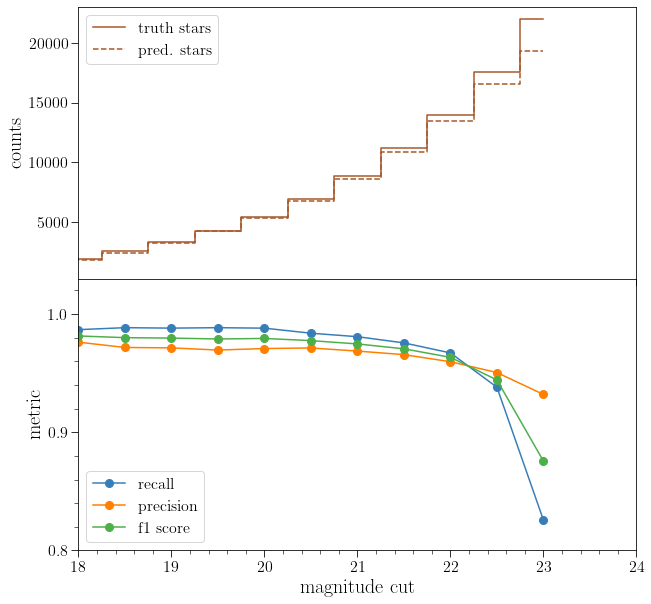

In [45]:
#fig = make_detection_figure(mag_cuts, data, ylims=(0.8, 1.03), n_gap=10)

In [99]:
results

{'precision': 0.9762309193611145,
 'recall': 0.9868143200874329,
 'f1': 0.9814940690994263,
 'n_galaxies_detected': 0,
 'n_matches': tensor(1871),
 'n_matches_gal_coadd': tensor(0),
 'class_acc': tensor(1.),
 'conf_matrix': tensor([[   0,    0],
         [   0, 1871]]),
 'counts': {'tgcount': 0,
  'tscount': 1897,
  'egcount': 0,
  'escount': 1767,
  'n_matches_coadd_gal': 0,
  'n_matches_coadd_star': 1871}}

## Coadd decoder

In [46]:
## Get Full Catalogs

est_coadd = tile_est_coadd.cpu().to_full_params() # full estimated catalog from single exposure model

# parameters are now per image
est_coadd.plocs.shape

est_coadd['galaxy_bools'] = torch.zeros(est_coadd.batch_size, est_coadd.max_sources, 1) # only stars, did not train classification encoder



In [47]:
## Simple metrics

# encoder
from bliss.reporting import DetectionMetrics
metrics = DetectionMetrics()(truth, est_coadd)

In [48]:
metrics['f1'], metrics['precision'], metrics['recall']

(tensor(0.9445), tensor(0.9557), tensor(0.9335))

In [49]:
est_coadd_plocs = est_coadd.plocs
# obtain fluxes of matches
true_fluxes = []
est_coadd_fluxes = [] 
for ii in range(true_plocs.shape[0]):
    n_sources1, n_sources2 = truth.n_sources[ii].item(), est_coadd.n_sources[ii].item()
    if n_sources1 > 0 and n_sources2 > 0:
        plocs1 = true_plocs[ii]
        plocs2 = est_coadd_plocs[ii]
        mtrue, mest, dkeep, avg_distance = match_by_locs(plocs1, plocs2)
        tp = len(plocs2[mest][dkeep])  # n_matches
        
        fluxes1 = truth['star_fluxes'][ii][mtrue][dkeep]
        fluxes2 = est_coadd['star_fluxes'][ii][mest][dkeep]
        for jj in range(tp):
            flux1 = fluxes1[jj].item()
            flux2 = fluxes2[jj].item()
            assert flux1 > 0 and flux2 > 0
            true_fluxes.append(flux1)
            est_coadd_fluxes.append(flux2)

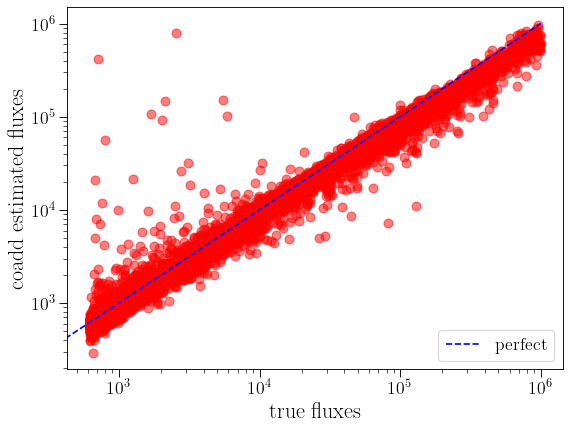

In [57]:
from matplotlib.pyplot import figure

figure(figsize=(8, 6), dpi=80)
plt.scatter(true_fluxes, est_coadd_fluxes, marker='o', color='r', alpha=0.5)
plt.plot([0, 1e6], [0, 1e6], 'b--', label='perfect')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('true fluxes')
plt.ylabel('coadd estimated fluxes')
plt.legend(prop={"size": 16})

In [85]:
# NOTE: need to add 'mag' to catalog
# ASSUMES only stars
from bliss.datasets.sdss import convert_flux_to_mag
est_coadd['mags'] = torch.zeros_like(est_coadd['star_fluxes'])
for ii in range(len(est_coadd.n_sources)):
    n_sources = est_coadd.n_sources[ii].item()
    est_coadd['mags'][ii, :n_sources] = convert_flux_to_mag(est_coadd['star_fluxes'][ii, :n_sources])

In [86]:
results_coadd = scene_metrics(truth, est_coadd, mag_min=-np.inf, mag_max=18)

In [87]:
data_coadd = compute_mag_bin_metrics(mag_cuts, truth, est_coadd)

100%|██████████| 12/12 [03:53<00:00, 19.47s/it]


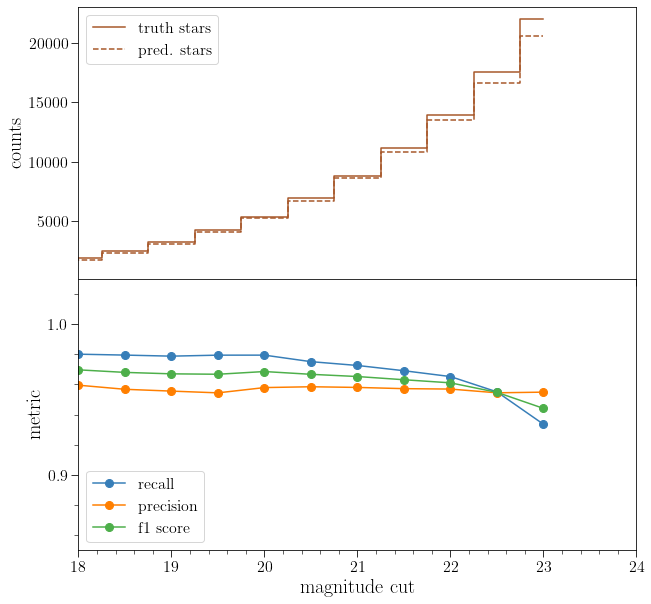

In [89]:
#fig = make_detection_figure(mag_cuts, data_coadd, ylims=(0.85, 1.03), n_gap=10)

In [105]:
data['precision']
data_coadd['precision']

tensor([0.9609, 0.9594, 0.9567, 0.9555, 0.9543, 0.9578, 0.9584, 0.9579, 0.9571,
        0.9569, 0.9544, 0.9548])

In [ ]:
def make_money_shot(
    mags,
    se,
    coadd,
    xlims=(18, 24),
    ylims=(0.7, 1.05),
    ratio=1,
    where_step="mid",
    n_gap=50,
):
    # precision / recall / f1 score
    single_exposure = se
    coadd = coadd
    # (1) precision / recall
    set_rc_params(tick_label_size=16, label_size=20)
    
    yticks = np.arange(np.round(ymin, 1), 1.1, 0.1)
    #format_plot(ax2, xlabel=r"\rm magnitude cut", ylabel="metric", yticks=yticks)
    plt.plot(mags[:, 1], single_exposure, "-o", label=r"\rm single exposure")
    plt.plot(mags[:, 1], coadd, "-o", label=r"\rm coadd")
    plt.legend(loc="lower left", prop={"size": 16})
    plt.set_xlim(xlims)
    plt.set_ylim(ylims)
    plt.yaxis.get_ticklocs(minor=True)
    plt.minorticks_on()

    return fig

In [108]:
mag_cuts2 = torch.arange(22.0, 23.5, 0.1)
mag_cuts1 = torch.full_like(mag_cuts2, fill_value=-np.inf)
mag_cuts = torch.column_stack((mag_cuts1, mag_cuts2))

In [111]:
money = compute_mag_bin_metrics(mag_cuts, truth, est)
money_coadd = compute_mag_bin_metrics(mag_cuts, truth, est_coadd)

100%|██████████| 15/15 [06:52<00:00, 27.52s/it]


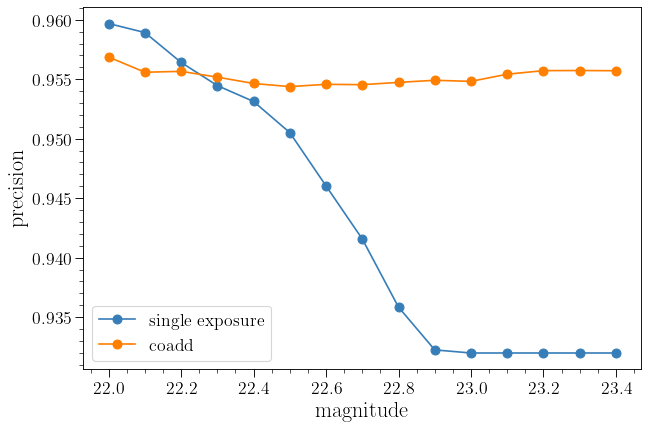

In [114]:
figure(figsize=(9, 6), dpi=80)
plt.plot(mag_cuts[:, 1], money['precision'], "-o", label=r"\rm single exposure")
plt.plot(mag_cuts[:, 1], money_coadd['precision'], "-o", label=r"\rm coadd")
plt.xlabel('magnitude')
plt.ylabel('precision')
plt.legend(loc="lower left", prop={"size": 16})
plt.minorticks_on()

## Check how single exposure data perform using model trained on coadd

Generating dataset: 100%|██████████| 100/100 [00:09<00:00, 10.88it/s]


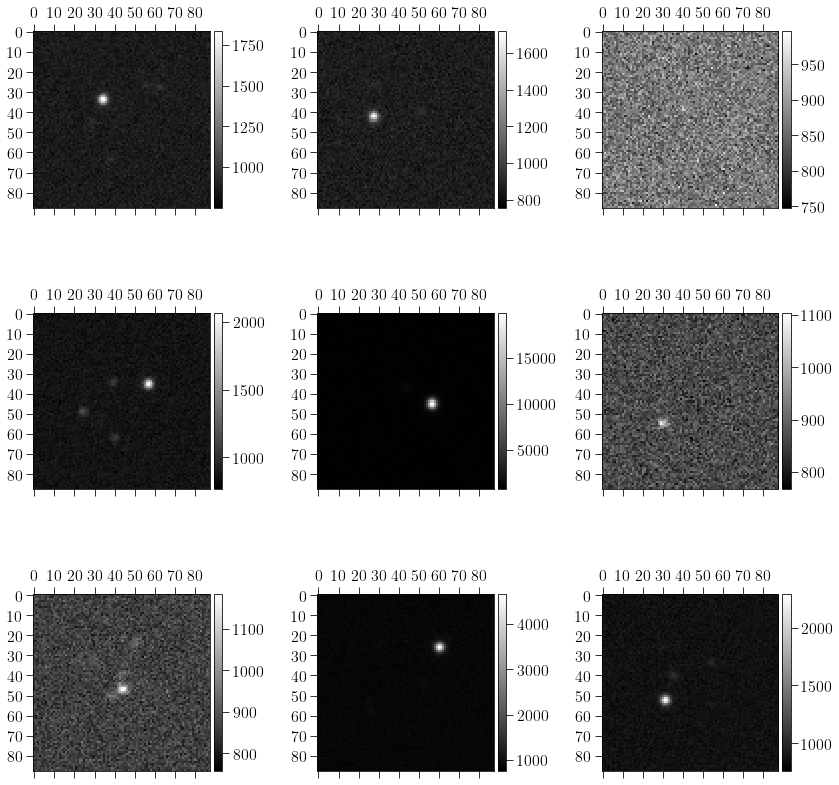

In [115]:
ds = instantiate(cfg.datasets.galsim_blends, batch_size=64, n_batches=100, num_workers=20)
from bliss.generate import generate
generate(ds, '/home/wmallory/bliss/case_studies/coadds/output/single_exposure_dataset.pt', '/home/wmallory/bliss/case_studies/coadds/output/single_exposure_dataset.png', 9, global_params=("background",))


In [117]:
sds = torch.load('/home/wmallory/bliss/case_studies/coadds/output/single_exposure_dataset.pt')
sds['images'].shape, sds['n_sources'].shape

(torch.Size([6400, 1, 88, 88]), torch.Size([6400, 10, 10]))

In [119]:
# format background (needs to be CONSTANT)
n_batches = sds['images'].shape[0]
slen = sds['images'].shape[-1]
background = rearrange(sds['background'], '1 h w -> 1 1 h w')
background = background.expand(n_batches, 1, slen, slen)

In [120]:
# run (single-exposure) model prediction 
tile_est = encoder.variational_mode(sds['images'], background)

Encoding ptiles: 640it [00:20, 30.80it/s]


In [130]:
# run (coadd) model prediction 
tile_est_coadd = encoder_coadd.variational_mode(sds['images'], background)

Encoding ptiles: 640it [00:20, 30.67it/s]


In [122]:
# load true catalog
catalog_dict = {
    "locs": sds["locs"],
    "star_log_fluxes": sds["star_log_fluxes"],
    "galaxy_bools": sds["galaxy_bools"],
    "n_sources": sds["n_sources"],
    "star_fluxes": sds['star_fluxes']
}

In [123]:
true_tile_catalog = TileCatalog(4, catalog_dict)
truth = true_tile_catalog.to_full_params()

In [124]:
est = tile_est.cpu().to_full_params() # full estimated catalog from single exposure model
est['galaxy_bools'] = torch.zeros(est.batch_size, est.max_sources, 1) # only stars, did not train classification encoder

In [125]:
# encoder
from bliss.reporting import DetectionMetrics
metrics = DetectionMetrics()(truth, est)

In [126]:
metrics['f1'], metrics['precision'], metrics['recall']

(tensor(0.8766), tensor(0.9318), tensor(0.8275))

In [131]:
## Get Full Catalogs

est_coadd = tile_est_coadd.cpu().to_full_params() # full estimated catalog from single exposure model

# parameters are now per image
est_coadd.plocs.shape

est_coadd['galaxy_bools'] = torch.zeros(est_coadd.batch_size, est_coadd.max_sources, 1) # only stars, did not train classification encoder



In [132]:
## Simple metrics

# encoder
from bliss.reporting import DetectionMetrics
metrics = DetectionMetrics()(truth, est_coadd)

In [133]:
metrics['f1'], metrics['precision'], metrics['recall']

(tensor(0.4012), tensor(0.2627), tensor(0.8488))